# Taylor and Maclaurin Polynomials


Maclaurin Polynomial:
   3    
  x     
- ── + x
  6     

Taylor Polynomial:
       4                 3                 2                                 
(x - 1) ⋅sin(1)   (x - 1) ⋅cos(1)   (x - 1) ⋅sin(1)                          
─────────────── - ─────────────── - ─────────────── + (x - 1)⋅cos(1) + sin(1)
       24                6                 2                                 


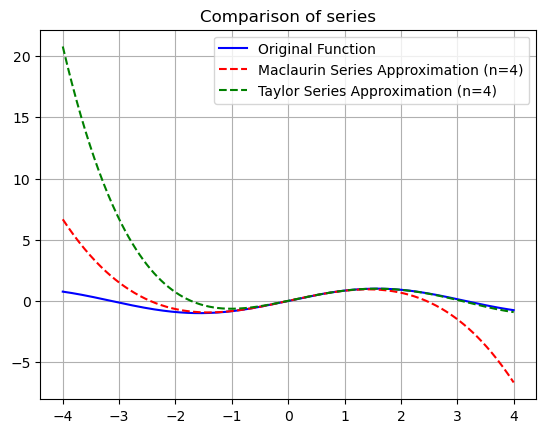

In [3]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.Symbol('x')

# Input
while True:
    try:
        expr_str = input("Enter f(x): ")
        if expr_str.strip() == "":
            break
        expr = sp.simplify(expr_str)

        n_str = input("Enter n: ")
        if n_str.strip() == "":
            break
        n = int(n_str)

        c_str = input("Enter c: ")
        if c_str.strip() == "":
            break
        c = sp.sympify(c_str)

        break
    except (ValueError, sp.SympifyError):
        print("The input is invalid. Please enter again in a valid form.")

# Maclaurin and Taylor Polynomial Calculation
def calculate_polynomial(base_expr, center, degree):
    if base_expr.subs(x, center) == sp.zoo:
        print(f"\nThe function {base_expr} is not defined at x = {center}.")
        return None
    polynomial = base_expr.subs(x, center)
    for i in range(1, degree + 1):
        if 'e^x' in expr_str:
            polynomial += (x - center)**i / sp.factorial(i)
        else:
            diff = sp.diff(base_expr, x, i).subs(x, center)
            if sp.solve(diff) != 0:
                polynomial += diff * (x - center)**i / sp.factorial(i)
    return polynomial

# Maclaurin Polynomial
if calculate_polynomial(expr, 0, n) != None:
    maclaurin = calculate_polynomial(expr, 0, n)
    print("\nMaclaurin Polynomial:")
    print(sp.pretty(maclaurin))
else: 
    maclaurin = None
    
# Taylor Polynomial
if calculate_polynomial(expr, c, n) != None:
    taylor = calculate_polynomial(expr, c, n)
    print("\nTaylor Polynomial:")
    print(sp.pretty(taylor))
else: 
    taylor = None
    

# Taylor Polynomial for graph
expr_str = expr_str.replace('e', str(np.exp(1)))
expr_graph = sp.simplify(expr_str)
if calculate_polynomial(expr, c, n) != None:
    taylor_graph = calculate_polynomial(expr_graph, c, n)
else: 
    taylor_graph = None
    
# Visualization
f = sp.lambdify(x, expr_graph, "numpy")
x_values = np.linspace(-4, 4, 500)

discontinuities = list(sp.solveset(sp.denom(expr), x, domain=sp.S.Reals))
discontinuities = [-np.inf] + sorted(discontinuities) + [np.inf]
try:
    for i in range(len(discontinuities) - 1):
        x_values_interval = x_values[(x_values > discontinuities[i]) & (x_values < discontinuities[i + 1])]

        if len(x_values_interval) > 0:
            y_values_func = f(x_values_interval)
            plt.plot(x_values_interval, y_values_func, label = "Original Function", color = 'blue')

            if maclaurin is not None:
                maclaurin_ = sp.lambdify(x, maclaurin, "numpy")
                y_values_maclaurin = maclaurin_(x_values_interval)
                plt.plot(x_values_interval, y_values_maclaurin, label="Maclaurin Series Approximation (n={})".format(n), linestyle = '--', color = 'red')

            if taylor is not None:
                taylor_ = sp.lambdify(x, taylor_graph, "numpy")
                y_values_taylor = taylor_(x_values_interval)
                plt.plot(x_values_interval, y_values_taylor, label="Taylor Series Approximation (n={})".format(n), linestyle = '--', color = 'green')

    plt.title("Comparison of series")
    plt.xlabel=('x')
    plt.ylabel=('y')
    plt.legend()
    plt.grid(True)
    plt.show()
except Exception as e:
    print("Graph cannot be plotted")

# Approximating Pi using arctan identity and Ramanjuan series

In [18]:
from mpmath import mp
import math

# Precision
mp.dps = 50
n = mp.arange(10000)


# Arctan identity 
n = mp.arange(10000)
arctan1 = mp.fsum(((-1)**n / (2*n + 1)) for n in n)
pi_arctan1 = 4 * arctan1

pi_arctan2 = 4 * (4 * mp.atan(mp.mpf(1)/5) - mp.atan(mp.mpf(1)/239))


# Ramanujan series
ramanujan = mp.fsum((mp.factorial(4*n)*(1103 + 26390*n)) / ((mp.factorial(n)**4) * (396**(4*n))) for n in n)
A = 2*mp.sqrt(2) / 9801
pi_ramanujan = 1 / (A * ramanujan)


# Comparison
comparison1 = mp.fabs(pi_arctan1 - pi_ramanujan)
comparison2 = mp.fabs(pi_arctan2 - pi_ramanujan)
diff_arctan_real1 = mp.fabs(mp.pi - pi_arctan1)
diff_arctan_real2 = mp.fabs(mp.pi - pi_arctan2)
diff_ramanujan_real = mp.fabs(mp.pi - pi_ramanujan)

print(f"Approximation of pi using arctan identity №1: {pi_arctan1}")
print(f"Approximation of pi using arctan identity №2: {pi_arctan2}")
print(f"Approximation of pi using Ramanujan series: {pi_ramanujan}")
print(f"True value of pi: {mp.pi}")
print()
print(f"Difference between the approximations (Arctan1 and Ramanjuan)): {comparison1}")
print(f"Difference between the approximations (Arctan2 and Ramanjuan)): {comparison2}")
print(f"Absolute error using arctan identity №1: {diff_arctan_real1}")
print(f"Absolute error using arctan identity №2: {diff_arctan_real2}")
print(f"Absolute error using Ramanujan series: {diff_ramanujan_real}")

Approximation of pi using arctan identity №1: 3.1414926535900432384595183833748153787870136427442
Approximation of pi using arctan identity №2: 3.1415926535897932384626433832795028841971693993751
Approximation of pi using Ramanujan series: 3.1415926535897932384626433832795028841971693993751
True value of pi: 3.1415926535897932384626433832795028841971693993751

Difference between the approximations (Arctan1 and Ramanjuan)): 0.000099999999750000003124999904687505410155756630925352
Difference between the approximations (Arctan2 and Ramanjuan)): 5.3455294201843912922810729343029637576303937602101e-51
Absolute error using arctan identity №1: 0.000099999999750000003124999904687505410155756630925352
Absolute error using arctan identity №2: 5.3455294201843912922810729343029637576303937602101e-51
Absolute error using Ramanujan series: 0.0


# Pi Approximation

In [5]:
from decimal import Decimal, getcontext

getcontext().prec = 10000
C = 426880 * Decimal(10005).sqrt()
K = 6
M = 1
X = 1
L = 13591409
S = L
for i in range(1, 10000):
    M = (K**3 - 16*K) * M // i**3
    K += 12
    L += 545140134
    X *= -262537412640768000
    S += Decimal(M * L) / X
pi = C / S

with open('pi.txt', 'w') as f:
    f.write(str(pi))


Approximation of Pi with 1000 decimal places: 3.1415926535897932384626433832795028841971693993751058209749445923078164062862089986280348253421170679821480865132823066470938446095505822317253594081284811174502841027019385211055596446229489549303819644288109756659334461284756482337867831652712019091456485669234603486104543266482133936072602491412737245870066063155881748815209209628292540917153643678925903600113305305488204665213841469519415116094330572703657595919530921861173819326117931051185480744623799627495673518857527248912279381830119491298336733624406566430860213949463952247371907021798609437027705392171762931767523846748184676694051320005681271452635608277857713427577896091736371787214684409012249534301465495853710507922796892589235420199561121290219608640344181598136297747713099605187072113499999983729780499510597317328160963185950244594553469083026425223082533446850352619311881710100031378387528865875332083814206171776691473035982534904287554687311595628638823537875937519577818

# Fourier Series

Enter f(x): x
Enter n_terms: 5


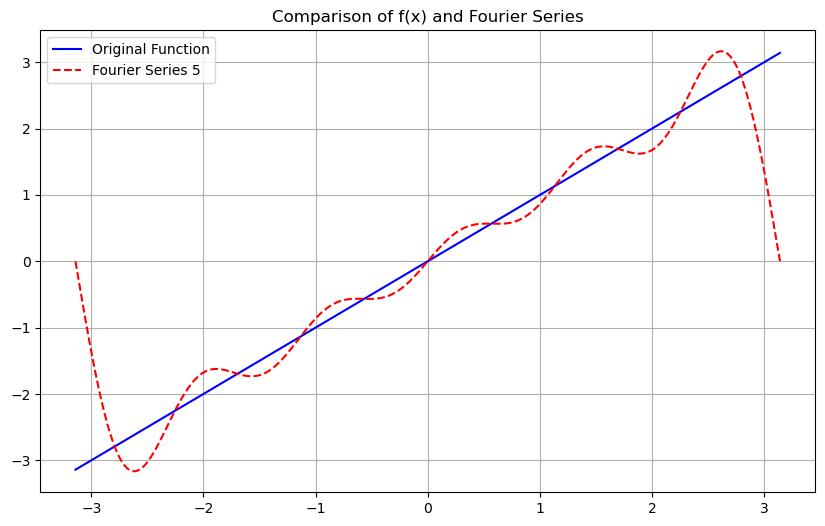

In [4]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.symbols('x')

while True:
    try:
        expr_str = input("Enter f(x): ")
        if expr_str.strip() == "":
            break
        expr = sp.simplify(expr_str)
        
        n_terms_str = input("Enter n_terms: ")
        if n_terms_str.strip() == "":
            break
        n_terms = int(n_terms_str)
        
        break
    except (ValueError, sp.SympifyError):
        print("The input is invalid. Please enter again in a valid form.")


a0 = (1/(2*sp.pi)) * sp.integrate(expr, (x, -sp.pi, sp.pi))
an = [(1/sp.pi) * sp.integrate(expr * sp.cos(n * x), (x, -sp.pi, sp.pi)) for n in range(1, n_terms+1)]
bn = [(1/sp.pi) * sp.integrate(expr * sp.sin(n * x), (x, -sp.pi, sp.pi)) for n in range(1, n_terms+1)]

fourier_series = a0/2 + sum(a * sp.cos(n * x) + b * sp.sin(n * x) for n, (a, b) in enumerate(zip(an, bn), start=1))

x_values = np.linspace(-np.pi, np.pi, 400)
f_lambda = sp.lambdify(x, expr, 'numpy')
series_lambda = sp.lambdify(x, fourier_series, 'numpy')

plt.figure(figsize=(10, 6))
plt.plot(x_values, f_lambda(x_values), label='Original Function', color='blue')
plt.plot(x_values, series_lambda(x_values), label=f'Fourier Series {n_terms}', linestyle='--', color='red')

plt.title('Comparison of f(x) and Fourier Series')
plt.xlabel=('x')
plt.ylabel=('y')
plt.legend()
plt.grid(True)
plt.show()

